In [6]:
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [7]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [8]:
import geopandas as gpd
from libpysal.weights import Queen

gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp").sort_values("LSOA21CD").reset_index(drop=True)

w = Queen.from_dataframe(gdf)
edges, weights = [], []

for src, neighbors in w.neighbors.items():
    for tgt in neighbors:
        geom_src = gdf.geometry.iloc[src]
        geom_tgt = gdf.geometry.iloc[tgt]
        inter = geom_src.intersection(geom_tgt)
        weight = inter.length if inter.length > 0 else 0.001
        edges.append([src, tgt])
        weights.append(weight)
        edges.append([tgt, src])
        weights.append(weight)
        
edge_index = torch.tensor(edges, dtype=torch.long).T
edge_weight = torch.tensor(weights, dtype=torch.float32)

C:\Users\wbwha\AppData\Local\Temp\ipykernel_8812\3828378298.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [9]:
SES_train = pd.read_csv("../Output/Pred Input/SES_train.csv")

X_train_sbert = torch.load("../Output/Pred Input/embedding_only_xgboost_gcn.pt")
X_train_sbert =X_train_sbert["X"]
X_train_topic = torch.load("../Output/Pred Input/topic_all_xgboost_gcn.pt")
X_train_topic =X_train_topic["X"]
X_train_topic50 = torch.load("../Output/Pred Input/topic_top50_train_xgboost_gcn.pt")
X_train_topic50 = X_train_topic50["X"]
X_train_topic100 = torch.load("../Output/Pred Input/topic_top100_train_xgboost_gcn.pt")
X_train_topic100 = X_train_topic100["X"]
X_train_topic200 = torch.load("../Output/Pred Input/topic_top200_train_xgboost_gcn.pt")
X_train_topic200 = X_train_topic200["X"]
X_train_topic500 = torch.load("../Output/Pred Input/topic_top500_train_xgboost_gcn.pt")
X_train_topic500 = X_train_topic500["X"]

y_train = torch.load("../Output/Pred Input/y_train_5.pt")

X_train_ses = SES_train.drop(columns=["LSOA21CD"]).values
X_train_ses = torch.tensor(X_train_ses, dtype=torch.float32)

# X_train_topic_ses = torch.cat([X_train_topic, X_train_ses], dim=1)
# X_train_sbert_ses = torch.cat([X_train_sbert, X_train_ses], dim=1)
# X_train_all = torch.cat([X_train_sbert, X_train_topic, X_train_ses], dim=1)

In [10]:
# =========================
# 0) Imports & config (adjust paths/vars to your env)
# =========================
import os, numpy as np, pandas as pd, torch
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

candidates = {
    "ses":          X_train_ses,
    "sbert":        X_train_sbert,
    "topic_all":    X_train_topic,
    "topic_top50":  X_train_topic50,
    "topic_top100": X_train_topic100,
    "topic_top200": X_train_topic200,
    "topic_top500": X_train_topic500,
}

# Assumed to exist from your environment:
#   - y_train               : torch.LongTensor [N]
#   - edge_index, edge_weight
#   - candidates (dict)     : {name: X_tensor [N, F]} for static features
#   - GentrificationGCN     : your model class (GCN-MLP head)

from Hybrid_Models.Gen_GCN_MLP import GentrificationGCN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = int(len(torch.unique(y_train)))

# Fixed seeds (same style as your LSTM script)
import random
random.seed(42)
SEEDS = random.sample(range(10000), 10)

# Training hyperparams (match GCN+LSTM style where possible)
LR = 1e-3
WEIGHT_DECAY = 5e-4
MAX_EPOCHS = 100
PATIENCE = 50
HIDDEN = 64
DROPOUT = 0.3

USE_FOCAL = False
FOCAL_GAMMA = 2.0

# Unified class weights from the full training set (optional; helps imbalance)
y_np_full = y_train.cpu().numpy()
classes_all = np.unique(y_np_full)
weights_all = compute_class_weight(class_weight='balanced', classes=classes_all, y=y_np_full)
class_weights_tensor = torch.tensor(weights_all, dtype=torch.float32, device=device)

if USE_FOCAL:
    from Loss_Functions.Focal_Loss import FocalLossMultiClass
    def make_criterion():
        return FocalLossMultiClass(alpha=class_weights_tensor, gamma=FOCAL_GAMMA)
else:
    def make_criterion():
        return torch.nn.CrossEntropyLoss()

# =========================
# 1) Stratified split util (same as your LSTM script)
# =========================
def stratified_split_indices(y_np: np.ndarray, val_ratio=0.2, seed=42):
    """Return train and val indices with class-stratified sampling."""
    train_idx, val_idx = [], []
    rng = np.random.RandomState(seed)
    for label in np.unique(y_np):
        idx = np.where(y_np == label)[0]
        n = len(idx); n_val = max(1, int(n * val_ratio))
        shuffled = rng.permutation(idx)
        val_idx.extend(shuffled[:n_val])
        train_idx.extend(shuffled[n_val:])
    return np.array(train_idx), np.array(val_idx)

# =========================
# 2) Train one split (macro-F1 early stopping), return metrics
# =========================
def train_eval_one_split(X: torch.Tensor,
                         y: torch.Tensor,
                         edge_index,
                         edge_weight=None,
                         train_idx=None,
                         val_idx=None,
                         seed=42):
    """Train one GCN-MLP instance and return val metrics: macro/weighted F1, accuracy."""
    # Reproducibility
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Move data
    X_t = X.to(device)
    y_t = y.to(device)
    ei  = edge_index.to(device)
    ew  = edge_weight.to(device) if edge_weight is not None else None

    # Model
    model = GentrificationGCN(
        in_channels=int(X_t.shape[1]),
        hidden_channels=HIDDEN,
        dropout_rate=DROPOUT,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = make_criterion()

    best_macro = -1.0
    best_state = None
    patience = PATIENCE

    # Train with early stopping on macro-F1
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        out = model(X_t, ei, ew)            # logits [N, C]
        loss = criterion(out[train_idx], y_t[train_idx])
        loss.backward()
        optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            logits_val = model(X_t, ei, ew)[val_idx]
            y_pred = logits_val.argmax(dim=1).detach().cpu().numpy()
            y_true = y_t[val_idx].cpu().numpy()
            macro_f1 = f1_score(y_true, y_pred, average="macro")

        if macro_f1 > best_macro:
            best_macro = macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = PATIENCE
        else:
            patience -= 1
            if patience == 0:
                break

    # Load best state and compute final val metrics
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        logits_val = model(X_t, ei, ew)[val_idx]
        y_pred = logits_val.argmax(dim=1).detach().cpu().numpy()
        y_true = y_t[val_idx].cpu().numpy()

    metrics = {
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "accuracy":    accuracy_score(y_true, y_pred),
    }
    return metrics

# =========================
# 3) Evaluate all candidates across seeds; build summary + per-seed long
# =========================
results = []
for name, X in candidates.items():
    y_np = y_train.cpu().numpy()
    macro_list, weighted_list, acc_list = [], [], []
    per_seed = {"macro_f1": [], "weighted_f1": [], "accuracy": []}

    for s in SEEDS:
        tr_idx, va_idx = stratified_split_indices(y_np, val_ratio=0.2, seed=s)
        m = train_eval_one_split(
            X, y_train,
            edge_index=edge_index,
            edge_weight=edge_weight,
            train_idx=tr_idx, val_idx=va_idx, seed=s
        )
        macro_list.append(m["macro_f1"]);      per_seed["macro_f1"].append(m["macro_f1"])
        weighted_list.append(m["weighted_f1"]); per_seed["weighted_f1"].append(m["weighted_f1"])
        acc_list.append(m["accuracy"]);        per_seed["accuracy"].append(m["accuracy"])

    result = {
        "dataset": name,
        "n_features": int(X.shape[1]),
        "macro_f1_mean": float(np.mean(macro_list)),
        "macro_f1_std":  float(np.std(macro_list)),
        "weighted_f1_mean": float(np.mean(weighted_list)),
        "weighted_f1_std":  float(np.std(weighted_list)),
        "accuracy_mean": float(np.mean(acc_list)),
        "accuracy_std":  float(np.std(acc_list)),
        "per_seed": per_seed,
    }
    print(f"{name:12s} | F={X.shape[1]:4d} | "
          f"macro={result['macro_f1_mean']:.4f}±{result['macro_f1_std']:.4f}  "
          f"weighted={result['weighted_f1_mean']:.4f}±{result['weighted_f1_std']:.4f}  "
          f"acc={result['accuracy_mean']:.4f}±{result['accuracy_std']:.4f}")
    results.append(result)

# Sort by primary metric
results_sorted = sorted(results, key=lambda d: d["macro_f1_mean"], reverse=True)

# Summary DataFrame
df_summary = pd.DataFrame([
    {
        "dataset": r["dataset"],
        "n_features": r["n_features"],
        "macro_f1_mean": r["macro_f1_mean"],
        "macro_f1_std":  r["macro_f1_std"],
        "weighted_f1_mean": r["weighted_f1_mean"],
        "weighted_f1_std":  r["weighted_f1_std"],
        "accuracy_mean": r["accuracy_mean"],
        "accuracy_std":  r["accuracy_std"],
    }
    for r in results_sorted
])

# Per-seed long DataFrame
rows = []
for r in results_sorted:
    ds = r["dataset"]
    for i, s in enumerate(SEEDS):
        rows.append({
            "dataset": ds,
            "seed": s,
            "macro_f1": r["per_seed"]["macro_f1"][i],
            "weighted_f1": r["per_seed"]["weighted_f1"][i],
            "accuracy": r["per_seed"]["accuracy"][i],
        })
df_long = pd.DataFrame(rows)

# Save to disk
out_dir = "../Output/Performance"
os.makedirs(out_dir, exist_ok=True)
csv_summary = os.path.join(out_dir, "gcn_mlp_dataset_comparison.csv")
csv_long    = os.path.join(out_dir, "gcn_mlp_dataset_per_seed_long.csv")
df_summary.to_csv(csv_summary, index=False)
df_long.to_csv(csv_long, index=False)

print("\n=== Ranking (by macro F1 mean) ===")
print(df_summary[["dataset", "n_features", "macro_f1_mean", "macro_f1_std",
                  "weighted_f1_mean", "weighted_f1_std", "accuracy_mean", "accuracy_std"]])
print(f"\nSaved summary to: {csv_summary}")
print(f"Saved per-seed to: {csv_long}")

ses          | F=  84 | macro=0.4877±0.0191  weighted=0.6340±0.0130  acc=0.6538±0.0104
sbert        | F= 384 | macro=0.4251±0.0149  weighted=0.5728±0.0116  acc=0.5837±0.0121
topic_all    | F=1174 | macro=0.4166±0.0112  weighted=0.5629±0.0075  acc=0.5854±0.0075
topic_top50  | F=  50 | macro=0.2816±0.0186  weighted=0.4553±0.0135  acc=0.5351±0.0064
topic_top100 | F= 100 | macro=0.3547±0.0159  weighted=0.5145±0.0112  acc=0.5675±0.0073
topic_top200 | F= 200 | macro=0.3926±0.0161  weighted=0.5452±0.0099  acc=0.5738±0.0093
topic_top500 | F= 500 | macro=0.4107±0.0164  weighted=0.5561±0.0130  acc=0.5716±0.0146

=== Ranking (by macro F1 mean) ===
        dataset  n_features  macro_f1_mean  macro_f1_std  weighted_f1_mean  \
0           ses          84       0.487688      0.019141          0.634000   
1         sbert         384       0.425123      0.014853          0.572796   
2     topic_all        1174       0.416553      0.011152          0.562949   
3  topic_top500         500       0.410746 

In [5]:
import os, itertools, random

from sklearn.metrics import f1_score, accuracy_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

from sklearn.utils.class_weight import compute_class_weight
from Loss_Functions.Focal_Loss import FocalLossMultiClass
from Hybrid_Models.Gen_GCN_MLP import GentrificationGCN   # GCN model (no LSTM)

# ------------------------------------------------------------
# Inputs assumed available:
#   X_train:    [N, F] tensor on device
#   y_train:    [N]    long tensor (class labels)
#   edge_index, edge_weight: GCN graph
# ------------------------------------------------------------
X_train = X_train_sbert

device = X_train.device if X_train.is_cuda else ("cuda" if torch.cuda.is_available() else "cpu")
X_train = X_train.to(device)
y_train = y_train.to(device)
n_classes = int(len(torch.unique(y_train)))
in_channels = int(X_train.shape[1])

# Fixed 5-fold CV over nodes (stratified by label)
y_np = y_train.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_indices = list(skf.split(np.arange(len(y_np)), y_np))

# Search space for pure GCN
search_space = {
    "hidden_channels": [64, 128],
    "dropout":         [0.1, 0.3],
    "lr":              [1e-2, 1e-3],
    "weight_decay":    [5e-4, 1e-3],
}
def product_dict(d):
    keys = list(d.keys())
    for values in itertools.product(*[d[k] for k in keys]):
        yield dict(zip(keys, values))

# Loss variants (from script 1 logic)
def compute_class_weights_on_train(y_np_train, num_classes, device):
    classes_present = np.unique(y_np_train)
    weights_partial = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_np_train)
    full = np.zeros(num_classes, dtype=np.float32)
    for i, cls in enumerate(classes_present):
        full[int(cls)] = weights_partial[i]
    if (full == 0).any():
        nz = full[full > 0]
        full[full == 0] = nz.min() if len(nz) > 0 else 1.0
    return torch.tensor(full, dtype=torch.float32, device=device)

loss_variants = {
    "CE":           lambda w: torch.nn.CrossEntropyLoss(),
    "Focal_gamma1": lambda w: FocalLossMultiClass(alpha=w, gamma=1.0),
    "Focal_gamma2": lambda w: FocalLossMultiClass(alpha=w, gamma=2.0),
}

# Training control
seeds = [0, 1, 2]      # increase if compute allows
num_epochs = 100
eval_every = 5
early_stop_patience = 10
early_stop_min_delta = 1e-4
monitor_metric = "val_macro_f1"

def eval_on_mask(logits, y_true_tensor, mask):
    y_true = y_true_tensor[mask].cpu().numpy()
    y_pred = logits[mask].argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, f1_macro, f1_weighted, rec_macro, y_true, y_pred

def train_one_run(cfg, loss_name, tr_idx, va_idx, seed):
    # Build boolean masks on device
    tr_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); tr_mask[tr_idx] = True
    va_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); va_mask[va_idx] = True

    # Deterministic-ish behavior
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Model
    model = GentrificationGCN(
        in_channels=in_channels,
        hidden_channels=cfg["hidden_channels"],
        dropout_rate=cfg["dropout"],
        num_classes=n_classes
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    # Loss with per-fold class weights (on train only)
    class_w = compute_class_weights_on_train(y_np[tr_idx], n_classes, device)
    criterion = loss_variants[loss_name](class_w)

    # Early stopping state
    best_metric = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0

    # Training history for one representative seed/fold
    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": [],
               "val_weighted_f1": [], "val_macro_recall": []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(X_train, edge_index, edge_weight)
        loss = criterion(out[tr_mask], y_train[tr_mask])
        loss.backward()
        optimizer.step()

        if (epoch % eval_every == 0) or (epoch == 1) or (epoch == num_epochs):
            model.eval()
            with torch.no_grad():
                out_eval = model(X_train, edge_index, edge_weight)
                val_logits = out_eval[va_mask]
                val_loss = criterion(val_logits, y_train[va_mask]).item()

                acc, f1m, f1w, recm, _, _ = eval_on_mask(out_eval, y_train, va_mask)

            # Log
            history["epoch"].append(epoch)
            history["train_loss"].append(float(loss.item()))
            history["val_loss"].append(float(val_loss))
            history["val_acc"].append(float(acc))
            history["val_macro_f1"].append(float(f1m))
            history["val_weighted_f1"].append(float(f1w))
            history["val_macro_recall"].append(float(recm))

            current = f1m if monitor_metric == "val_macro_f1" else acc
            improved = (current - best_metric) > early_stop_min_delta
            if improved:
                best_metric = current
                best_epoch = epoch
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= early_stop_patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Final evaluation on val
    model.eval()
    with torch.no_grad():
        out_final = model(X_train, edge_index, edge_weight)
        acc, f1m, f1w, recm, y_true, y_pred = eval_on_mask(out_final, y_train, va_mask)
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        report = classification_report(y_true, y_pred, digits=4, zero_division=0)

    return {
        "final_acc": acc, "final_macro_f1": f1m, "final_weighted_f1": f1w,
        "final_macro_recall": recm, "best_epoch": best_epoch,
        "history": history, "report": report, "confusion_matrix": cm
    }

# Run grid × loss × (5 folds) × seeds
results = []
for cfg in product_dict(search_space):
    for loss_name in ["CE", "Focal_gamma1", "Focal_gamma2"]:
        fold_metrics = []
        rep_history = None; rep_report = None; rep_cm = None

        for fold_id, (tr_idx, va_idx) in enumerate(fold_indices, 1):
            seed_metrics = []
            for s in seeds:
                m = train_one_run(cfg, loss_name, tr_idx, va_idx, seed=s)
                seed_metrics.append(m)

            # keep representative artifacts
            if rep_history is None:
                rep_history = seed_metrics[0]["history"]
                rep_report = seed_metrics[0]["report"]
                rep_cm = seed_metrics[0]["confusion_matrix"]

            # average across seeds (within fold)
            fold_metrics.append({
                "acc": np.mean([x["final_acc"] for x in seed_metrics]),
                "macro_f1": np.mean([x["final_macro_f1"] for x in seed_metrics]),
                "weighted_f1": np.mean([x["final_weighted_f1"] for x in seed_metrics]),
                "macro_recall": np.mean([x["final_macro_recall"] for x in seed_metrics]),
                "best_epoch": np.mean([x["best_epoch"] for x in seed_metrics]),
            })

        # average across folds
        avg_acc = float(np.mean([fm["acc"] for fm in fold_metrics]))
        avg_macro = float(np.mean([fm["macro_f1"] for fm in fold_metrics]))
        avg_weighted = float(np.mean([fm["weighted_f1"] for fm in fold_metrics]))
        avg_recall = float(np.mean([fm["macro_recall"] for fm in fold_metrics]))
        avg_best_epoch = int(np.round(np.mean([fm["best_epoch"] for fm in fold_metrics])))

        results.append({
            "cfg": cfg, "loss": loss_name,
            "avg_acc": avg_acc, "avg_macro_f1": avg_macro,
            "avg_weighted_f1": avg_weighted, "avg_macro_recall": avg_recall,
            "avg_best_epoch": avg_best_epoch,
            "history": rep_history, "report_seed0": rep_report, "cm_seed0": rep_cm
        })

# Save leaderboard CSV
os.makedirs("../Output/Performance", exist_ok=True)
df = pd.DataFrame([{
    **r["cfg"], "loss": r["loss"],
    "avg_macro_f1": r["avg_macro_f1"],
    "avg_weighted_f1": r["avg_weighted_f1"],
    "avg_accuracy": r["avg_acc"],
    "avg_macro_recall": r["avg_macro_recall"],
    "avg_best_epoch": r["avg_best_epoch"],
    "n_folds": 5, "seeds": len(seeds),
} for r in results])

df = df.sort_values(by=["avg_macro_f1", "avg_weighted_f1", "avg_accuracy"], ascending=False).reset_index(drop=True)
csv_path = "../Output/Performance/gcn_5fold_grid_results.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"Saved: {csv_path}")
print(df.head(10))

Saved: ../Output/Performance/gcn_5fold_grid_results.csv
   hidden_channels  dropout     lr  weight_decay          loss  avg_macro_f1  \
0               64      0.1  0.001        0.0005            CE      0.418239   
1               64      0.3  0.001        0.0005            CE      0.417299   
2               64      0.1  0.001        0.0010            CE      0.411865   
3               64      0.3  0.001        0.0010            CE      0.411020   
4               64      0.3  0.001        0.0010  Focal_gamma1      0.406418   
5               64      0.3  0.001        0.0005  Focal_gamma2      0.404518   
6               64      0.1  0.001        0.0005  Focal_gamma1      0.404342   
7               64      0.3  0.001        0.0005  Focal_gamma1      0.404106   
8               64      0.1  0.001        0.0010  Focal_gamma1      0.403440   
9              128      0.1  0.001        0.0005            CE      0.403032   

   avg_weighted_f1  avg_accuracy  avg_macro_recall  avg_best_ep

Epoch 001 | Val Acc: 0.1121 | Loss: 1.2933
Epoch 010 | Val Acc: 0.3644 | Loss: 1.1716
Epoch 020 | Val Acc: 0.3453 | Loss: 1.0713
Epoch 030 | Val Acc: 0.1942 | Loss: 0.9910
Epoch 040 | Val Acc: 0.2452 | Loss: 0.9209
Epoch 050 | Val Acc: 0.3934 | Loss: 0.8374
Epoch 060 | Val Acc: 0.3724 | Loss: 0.7514
Epoch 070 | Val Acc: 0.3383 | Loss: 0.6414
Epoch 080 | Val Acc: 0.4254 | Loss: 0.5514
Epoch 090 | Val Acc: 0.4194 | Loss: 0.4607
Epoch 100 | Val Acc: 0.5055 | Loss: 0.3918
              precision    recall  f1-score   support

           0     0.7846    0.7041    0.7422       507
           1     0.2267    0.2656    0.2446       128
           2     0.2484    0.3611    0.2943       108
           3     0.3562    0.3611    0.3586       144
           4     0.2527    0.2054    0.2266       112

    accuracy                         0.5055       999
   macro avg     0.3737    0.3795    0.3733       999
weighted avg     0.5338    0.5055    0.5169       999



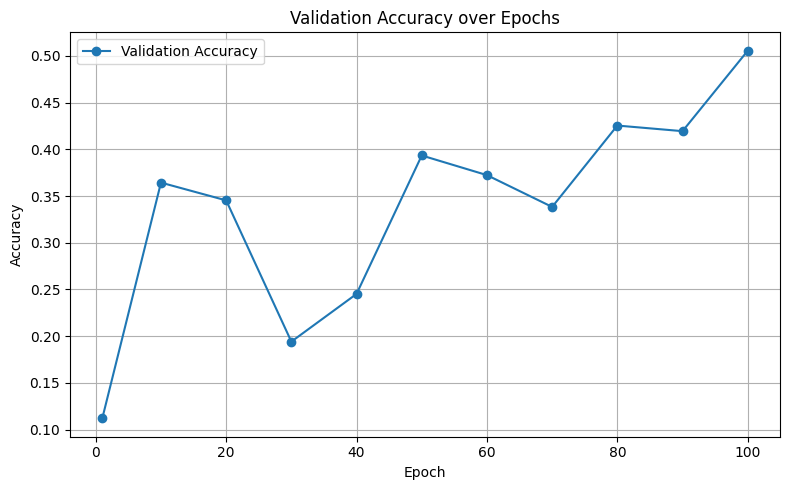

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# ===== 1) Prepare labels and stratified split (NO upsampling, avoid leakage) =====
y_all = y_train.cpu().numpy()
idx_all = np.arange(len(y_all))

# Stratified split on unique indices only
train_idx, val_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Boolean masks for full-graph training
train_mask = torch.zeros(len(y_all), dtype=torch.bool)
val_mask   = torch.zeros(len(y_all), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx]     = True

# Put labels on same device as features
device = X_train_sbert.device
y_all_tensor = torch.tensor(y_all, dtype=torch.long, device=device)

# ===== 2) Model and optimizer setup =====
in_channels     = X_train_sbert.shape[1]
hidden_channels = 64
dropout_rate    = 0.3
num_classes     = len(np.unique(y_all))

model_best = GentrificationGCN(in_channels, hidden_channels, dropout_rate, num_classes).to(device)
optimizer  = torch.optim.Adam(model_best.parameters(), lr=1e-3, weight_decay=5e-4)

# ===== 3) Class weights / Focal loss (computed only on training set) =====
y_train_subset = y_all[train_idx]
classes = np.unique(y_train_subset)

# Compute weights inversely proportional to class frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_subset
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

# Loss function: Focal loss with class weights
criterion = FocalLossMultiClass(alpha=class_weights_tensor, gamma=1.0)
# Alternative: standard weighted CrossEntropy
# criterion = torch.nn.CrossEntropyLoss()

# ===== 4) Training loop (evaluate in eval mode with fresh forward pass) =====
train_losses = []
val_accuracies = []

for epoch in range(1, 101):
    model_best.train()
    optimizer.zero_grad()

    # Forward pass on the full graph
    out = model_best(X_train_sbert, edge_index, edge_weight)
    loss = criterion(out[train_mask], y_all_tensor[train_mask])
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation step
    if epoch % 10 == 0 or epoch == 1:
        model_best.eval()
        with torch.no_grad():
            # Recompute output in eval mode (disable dropout etc.)
            out_eval = model_best(X_train_sbert, edge_index, edge_weight)
            preds = out_eval[val_mask].argmax(dim=1)
            acc = (preds == y_all_tensor[val_mask]).float().mean().item()
            val_accuracies.append((epoch, acc))
            print(f"Epoch {epoch:03d} | Val Acc: {acc:.4f} | Loss: {loss:.4f}")

# ===== 5) Final evaluation on validation set =====
model_best.eval()
with torch.no_grad():
    out_eval = model_best(X_train_sbert, edge_index, edge_weight)
    y_true = y_all_tensor[val_mask].cpu().numpy()
    y_pred = out_eval[val_mask].argmax(dim=1).cpu().numpy()

print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# ===== 6) Plot validation accuracy curve =====
if len(val_accuracies) > 0:
    epochs_plot, acc_plot = zip(*val_accuracies)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_plot, acc_plot, marker='o', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy over Epochs')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()